## Project Setup

### Install Kubectl for accessing GKE cluster for running ML Jobs

In [ ]:
!cat /content/aai-540-in1-fin-int-ai-agent/setup/install_gcp.sh

#!/bin/bash
set -e

INSTALL_DIR="/usr/local"
CLOUDSDK_ROOT="$INSTALL_DIR/google-cloud-sdk"

# Function to add gcloud to PATH for the current session
add_gcloud_to_path() {
  if [ -d "$CLOUDSDK_ROOT/bin" ] && [[ ":$PATH:" != *":$CLOUDSDK_ROOT/bin:"* ]]; then
    export PATH="$CLOUDSDK_ROOT/bin:$PATH"
    echo "Added Google Cloud SDK to PATH for current session." >&2
  fi
}

# Ensure the temporary directory exists
mkdir -p /tmp/gcloud_sdk_install
cd /tmp/gcloud_sdk_install \
  && curl -O https://dl.google.com/dl/cloudsdk/channels/rapid/google-cloud-sdk.zip \
  && unzip -q google-cloud-sdk.zip \
  && ./google-cloud-sdk/install.sh --usage-reporting=false --path-update=true --rc-path="~/.bashrc" --disable-installation-options \
  && rm -rf /usr/local/google-cloud-sdk \
  && mv ./google-cloud-sdk /usr/local/google-cloud-sdk

# Ensure the PATH is correctly updated in the current session


# Verify gcloud installation
#gcloud version

print("Google Cloud SDK has been re-installed and verified.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/AAI-540-IN1/aai-540-in1-fin-int-ai-agent /content/

In [ ]:
!cat /content/aai-540-in1-fin-int-ai-agent/setup/install_kubectl.sh

#!/bin/bash

# Check if kubectl is already installed
if ! command -v kubectl &> /dev/null
then
    echo "kubectl not found. Installing..."

    # Download the latest stable release of kubectl
    curl -LO "https://dl.k8s.io/release/$(curl -L -s https://dl.k8s.io/release/stable.txt)/bin/linux/amd64/kubectl"

    # Make the kubectl binary executable
    chmod +x ./kubectl

    # Move the binary to a directory in your PATH (e.g., /usr/local/bin)
    sudo mv ./kubectl /usr/local/bin/kubectl

    # Verify the installation
    kubectl version --client

    echo 'kubectl installed successfully!'
else
    echo 'kubectl is already installed.'
    kubectl version --client
fi

In [ ]:
%%bash
cd /content/aai-540-in1-fin-int-ai-agent/setup
chmod +x install_gcp.sh
chmod +x install_kubectl.sh
./install_gcp.sh
./install_kubectl.sh

Process is terminated.


In [ ]:
!echo "Updating Google Cloud SDK components..." >&2
!gcloud components update --quiet

!echo "Installing gke-gcloud-auth-plugin..." >&2
!gcloud components install gke-gcloud-auth-plugin --quiet

!echo "Google Cloud SDK and gke-gcloud-auth-plugin setup complete." >&2


Updating Google Cloud SDK components...
ERROR: (gcloud.components.update) The components management action could not be performed because the installation root of the Cloud SDK could not be located. If you previously used the Cloud SDK installer, you could re-install the SDK and retry again.
Installing gke-gcloud-auth-plugin...
ERROR: (gcloud.components.install) The components management action could not be performed because the installation root of the Cloud SDK could not be located. If you previously used the Cloud SDK installer, you could re-install the SDK and retry again.
Google Cloud SDK and gke-gcloud-auth-plugin setup complete.


In [ ]:
%%bash
cd /content/aai-540-in1-fin-int-ai-agent/setup
chmod +x install_kubectl.sh
./install_kubectl.sh


kubectl not found. Installing...
Client Version: v1.35.1
Kustomize Version: v5.7.1
kubectl installed successfully!


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 55.8M  100 55.8M    0     0  68.5M      0 --:--:-- --:--:-- --:--:-- 68.5M


### Install Relevant Python packages.

In [ ]:
project_dir = '/content/aai-540-in1-fin-int-ai-agent'

In [ ]:
!cat {project_dir}/setup/client_requirement.txt

# Utilities
pyyaml
tqdm
python-dotenv

In [ ]:
!pip install -r  {project_dir}/setup/client_requirement.txt --quiet

### Import Relevant Python Package

In [ ]:
import sys
import os
from dotenv import load_dotenv

import warnings
warnings.filterwarnings('ignore')


if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
    sys.path.insert(1, f"{project_dir}/src")

os.environ['PROJECT_DIR'] = project_dir

# Ensure Google Cloud SDK's bin directory is in PATH for gke-gcloud-auth-plugin
cloudsdk_bin_path = '/usr/local/google-cloud-sdk/bin'
if cloudsdk_bin_path not in os.environ.get('PATH', ''):
    os.environ['PATH'] = f"{cloudsdk_bin_path}:{os.environ.get('PATH', '')}"
    print(f"Added {cloudsdk_bin_path} to PATH.")

#load_dotenv(project_dir)

from util.config_loader import config_loader
from ingestion.setup_infra  import setup_data_lake
#from util.secret_parser import create_secret_from_env
from ingestion.load_raw_data import load_to_raw_bucket
from preprocessing import preprocess

print(f" Project folder: {os.getenv('PROJECT_DIR')}")
#print(f"Current PATH: {os.getenv('PATH')}")


Added /usr/local/google-cloud-sdk/bin to PATH.
 Project folder: /content/aai-540-in1-fin-int-ai-agent


In [ ]:
#create_secret_from_env()

## Infrastructure Provision

### Authentication & GCP Project Configuration

In [ ]:
project_id = config_loader.get('project.id')
print(f"Create Project environment in {config_loader.get('project.region')}")

Create Project environment in us-central1


In [ ]:
result = !gcloud auth login

In [ ]:
result = !gcloud config set project {config_loader.get('project.id')}
print(result[-1])

Updated property [core/project].


### Create Datalake in GCS and Bigquery

In [ ]:
setup_data_lake(project_id)

 GCS Bucket already exists: cfpb-raw-lake-sdk
BigQuery Dataset already exists: cfpb_analysis


### Kubernetes Cluster Creation for Running ML Jobs

In [ ]:
project_id = config_loader.get('project.id')
location = config_loader.get('project.region')
CLUSTER_NAME=config_loader.get("gke.cluster.name")
CLUSTER_NODE_COUNT=config_loader.get("gke.cluster.num_nodes")
CLUSTER_MACHINE_TYPE=config_loader.get("gke.cluster.machine_type")
WORKLOAD_POOL_FULL=f"{project_id}.svc.id.goog"
NODEPOOL_NAME=config_loader.get("gke.node_pool.name")
NODEPOOL_MACHINE_TYPE=config_loader.get("gke.node_pool.machine_type")
ACCELERATOR_TYPE=config_loader.get("gke.node_pool.accelerator.type")
ACCELERATOR_COUNT=config_loader.get("gke.node_pool.accelerator.count")
NODEPOOL_NUM_NODES=config_loader.get("gke.node_pool.num_nodes")
SCOPES=config_loader.get("gke.node_pool.scopes")
REPOSITORY_NAME=config_loader.get("gke.node_pool.repository_name")
GCP_SERVICE_ACCOUNT=config_loader.get("GCP_SERVICE_ACCOUNT")


# Ensure the script is executable
!chmod +x {project_dir}/setup/create_gke_cluster.sh

# Construct the command string and execute in a single bash shell
command_str = f"""
\"{project_dir}/setup/create_gke_cluster.sh\" \
  \"{CLUSTER_NAME}\" \
  \"{project_id}\" \
  \"{location}\" \
  \"{CLUSTER_MACHINE_TYPE}\" \
  \"{CLUSTER_NODE_COUNT}\" \
  \"{WORKLOAD_POOL_FULL}\" \
  \"{NODEPOOL_NAME}\" \
  \"{NODEPOOL_MACHINE_TYPE}\" \
  \"{ACCELERATOR_TYPE}\" \
  \"{ACCELERATOR_COUNT}\" \
  \"{NODEPOOL_NUM_NODES}\" \
  \"{SCOPES}\" \
  \"{REPOSITORY_NAME}\" \
  \"{GCP_SERVICE_ACCOUNT}\" \
"""
!bash -c "{command_str}"

Checking for existing GKE cluster: sdk-training-cluster in us-central1
GKE cluster sdk-training-cluster already exists. Skipping cluster creation.
Setting kubectl context for cluster: sdk-training-cluster
Fetching cluster endpoint and auth data.
kubeconfig entry generated for sdk-training-cluster.
Checking for existing node pool: gpu-pool in cluster sdk-training-cluster
Node pool gpu-pool already exists. Skipping creation.
Checking for existing Artifact Registry repository: sdk-training-repo in us-central1)
Artifact Registry repository sdk-training-repo already exists. Skipping creation.
Infrastructure setup complete.


In [ ]:
!kubectl annotate serviceaccount default \
    iam.gke.io/gcp-service-account=${os.getenv('GCP_SERVICE_ACCOUNT')}

serviceaccount/default annotated


## Data Ingestion

### Load Raw data in Datalake

In [ ]:
PROJECT = config_loader.get("PROJECT_ID")
RAW_BUCKET = config_loader.get('GCS_BUCKET')
LOCAL_RAW_FILE_PATH =  f"{project_dir}/data/{config_loader.get('data.raw_file_path').split('/')[-1]}"
DATASET = config_loader.get('bigquery.dataset')

In [ ]:

load_to_raw_bucket(PROJECT, RAW_BUCKET,LOCAL_RAW_FILE_PATH )


Uploading /content/aai-540-in1-fin-int-ai-agent/data/complaints2.csv to GCS bucket...
Success! File available in GCS


### Apply Transformation and Create Staging Table in Biguery

In [ ]:
preprocess.preprocess_raw_to_staging (PROJECT, DATASET, RAW_BUCKET)

In [ ]:
complaints_ds = preprocess.preprocess_data()


Number of records before removing records with Nan value : 1000


In [ ]:
preprocess.split_data(complaints_ds,100)

In [ ]:
complaints_ds.head(5)

,Unnamed: 0.1,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,3,5198150,2024-07-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I called XXXX and tried to make a full paymen...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,33880,NaN,Consent provided,Web,2024-07-29,Closed with explanation,Yes,NaN,9632676
1,7,5398465,2023-05-04,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,As indicated by the Fair Credit Reporting Act ...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,GA,30135,NaN,Consent provided,Web,2023-05-04,Closed with explanation,Yes,NaN,6930988
2,9,1975631,2025-06-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,Already shared with XXXX XXXX XXXXXXXX After s...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MS,39402,Older American,Consent provided,Web,2025-06-10,Closed with non-monetary relief,Yes,NaN,13992081
3,10,3363387,2021-08-10,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account status incorrect,I have a late payment on my account because I ...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",CO,807XX,NaN,Consent provided,Web,2021-08-10,Closed with explanation,Yes,NaN,4618604
4,11,1650024,2025-07-06,Debt collection,I do not know,Written notification about debt,Didn't receive enough information to verify debt,Resurgent Capital Services L.P . \nXXXX XXXX X...,NaN,Resurgent Capital Services L.P.,NY,XXXXX,NaN,Consent provided,Web,2025-07-06,Closed with non-monetary relief,Yes,NaN,14498128


## Preprocessing


Analyze the schema and sample data of the `complaints_ds` DataFrame to identify text features suitable for Gemma model pretraining (e.g., 'Consumer complaint narrative') and categorical features (e.g., 'Product', 'Issue', 'Company', 'State', 'Tags'). Subsequently, propose a strategy for preparing and storing these identified features in a BigQuery feature store.


Examine the schema and a sample of the `complaints_ds` DataFrame to understand the available columns and their data types. This will help in identifying potential features.


In [ ]:
print("DataFrame Info:")
complaints_ds.info()
print("\nFirst 5 rows of the DataFrame:")
complaints_ds.head()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Unnamed: 0.1                  147 non-null    int64 
 1   Unnamed: 0                    147 non-null    int64 
 2   Date received                 147 non-null    object
 3   Product                       147 non-null    object
 4   Sub-product                   147 non-null    object
 5   Issue                         147 non-null    object
 6   Sub-issue                     132 non-null    object
 7   Consumer complaint narrative  147 non-null    object
 8   Company public response       79 non-null     object
 9   Company                       147 non-null    object
 10  State                         146 non-null    object
 11  ZIP code                      147 non-null    object
 12  Tags                          23 non-null     object
 13  Cons

,Unnamed: 0.1,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,3,5198150,2024-07-29,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account information incorrect,I called XXXX and tried to make a full paymen...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,33880,NaN,Consent provided,Web,2024-07-29,Closed with explanation,Yes,NaN,9632676
1,7,5398465,2023-05-04,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,As indicated by the Fair Credit Reporting Act ...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,GA,30135,NaN,Consent provided,Web,2023-05-04,Closed with explanation,Yes,NaN,6930988
2,9,1975631,2025-06-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,Already shared with XXXX XXXX XXXXXXXX After s...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MS,39402,Older American,Consent provided,Web,2025-06-10,Closed with non-monetary relief,Yes,NaN,13992081
3,10,3363387,2021-08-10,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account status incorrect,I have a late payment on my account because I ...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",CO,807XX,NaN,Consent provided,Web,2021-08-10,Closed with explanation,Yes,NaN,4618604
4,11,1650024,2025-07-06,Debt collection,I do not know,Written notification about debt,Didn't receive enough information to verify debt,Resurgent Capital Services L.P . \nXXXX XXXX X...,NaN,Resurgent Capital Services L.P.,NY,XXXXX,NaN,Consent provided,Web,2025-07-06,Closed with non-monetary relief,Yes,NaN,14498128


### Identified Features and Proposed BigQuery Feature Store Strategy



**1. Feature Identification:**

*   **Text Features for Gemma Model Pretraining:**
    *   `Consumer complaint narrative`: This is the primary free-form text feature, directly suitable for language model pretraining.
    *   `Issue`, `Sub-issue`, `Company public response`, `Company response to consumer`: These columns also contain valuable textual information that could be used independently or concatenated with the `Consumer complaint narrative` to enrich the text input for the Gemma model. The model can learn context from these fields.

*   **Categorical Features:**
    *   `Product`, `Sub-product`, `Issue`, `Sub-issue`, `Company`, `State`, `Tags`, `Consumer consent provided?`, `Submitted via`, `Timely response?`, `Consumer disputed?`.
    *   These features represent discrete categories and are crucial for understanding the nature of complaints and for potential downstream classification or regression tasks.

*   **Other Relevant Features (for context/filtering/future use):**
    *   `Date received`, `Date sent to company`: These can be converted to datetime objects and used to extract temporal features (e.g., day of week, month, year) or to calculate durations.
    *   `ZIP code`: Can be treated as a categorical feature or used to derive broader geographical categories.
    *   `Complaint ID`: A unique identifier for each complaint, useful as a primary key in a feature store.

**2. Proposed Strategy for BigQuery Feature Store:**

To effectively leverage these features, especially for model training, we will prepare and store them in a BigQuery table acting as a feature store. This approach provides scalability, managed storage, and integration with other GCP services.

*   **Preprocessing Steps (before loading to BigQuery):**
    *   **Text Features:** Ensure `Consumer complaint narrative` (and other selected text fields) are clean (e.g., handle special characters, consistent formatting). For null values, these should be replaced with empty strings to avoid issues during training.
    *   **Categorical Features:** Handle null values by imputing with a placeholder like 'UNKNOWN' or the mode. For `Tags` and `ZIP code`, consider the cardinality; if too high, these might need aggregation or specific encoding strategies.
    *   **Date Features:** Convert `Date received` and `Date sent to company` to `datetime` objects and extract any desired temporal features (e.g., year, month). Convert them to `DATE` or `TIMESTAMP` type for BigQuery.
    *   **Column Selection:** Drop irrelevant columns such as `Unnamed: 0.1` and `Unnamed: 0` which appear to be indices.

*   **BigQuery Table Schema Design:**
    A BigQuery table, for example, `cfpb_analysis.complaints_features`, will be created with the following example schema:

    *   `complaint_id`: `INTEGER` (Unique identifier, primary key)
    *   `narrative_text`: `STRING` (Cleaned consumer complaint narrative)
    *   `product`: `STRING`
    *   `sub_product`: `STRING`
    *   `issue`: `STRING`
    *   `sub_issue`: `STRING`
    *   `company`: `STRING`
    *   `state`: `STRING`
    *   `zip_code`: `STRING`
    *   `tags`: `STRING` (or `ARRAY<STRING>` if multiple tags need to be stored individually)
    *   `consumer_consent_provided`: `BOOLEAN` (or `STRING` if exact values like 'Consent provided' are needed)
    *   `submitted_via`: `STRING`
    *   `timely_response`: `BOOLEAN`
    *   `consumer_disputed`: `BOOLEAN`
    *   `date_received`: `DATE`
    *   `date_sent_to_company`: `DATE`

*   **Loading Data to BigQuery:**
    The processed DataFrame will be uploaded to BigQuery, creating the new feature table. This can be done using pandas `to_gbq` function or by exporting to GCS and then using a BigQuery load job. This table will serve as the central repository for features, accessible for training, evaluation, and serving of ML models.

##### Identify Categorical Features

In [ ]:
categorical_columns = [
    'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Tags',
    'Consumer consent provided?', 'Submitted via', 'Company response to consumer', 'Timely response?', 'Consumer disputed?'
]

print("Analysis of Potential Categorical Features:")
print("------------------------------------------")
for col in categorical_columns:
    if col in complaints_ds.columns:
        unique_count = complaints_ds[col].nunique()
        print(f"Column: '{col}'")
        print(f"  Data Type: {complaints_ds[col].dtype}")
        print(f"  Number of Unique Values: {unique_count}")
        print(f"  Explanation: This column contains a limited number of distinct values, making it suitable for categorical encoding. It represents discrete categories rather than continuous measurements.\n")
    else:
        print(f"Column '{col}' not found in the DataFrame.\n")

Analysis of Potential Categorical Features:
------------------------------------------
Column: 'Product'
  Data Type: object
  Number of Unique Values: 12
  Explanation: This column contains a limited number of distinct values, making it suitable for categorical encoding. It represents discrete categories rather than continuous measurements.

Column: 'Sub-product'
  Data Type: object
  Number of Unique Values: 24
  Explanation: This column contains a limited number of distinct values, making it suitable for categorical encoding. It represents discrete categories rather than continuous measurements.

Column: 'Issue'
  Data Type: object
  Number of Unique Values: 34
  Explanation: This column contains a limited number of distinct values, making it suitable for categorical encoding. It represents discrete categories rather than continuous measurements.

Column: 'Sub-issue'
  Data Type: object
  Number of Unique Values: 46
  Explanation: This column contains a limited number of distinct va

## Feature Store Strategy



1. Define the preprocessing steps for the identified text and categorical features:
    a. **For Text Features** (e.g., 'Consumer complaint narrative', 'Issue', 'Sub-issue', 'Company public response', 'Company response to consumer'):
        *   **Missing Values:** Replace any `NaN` or null values with empty strings (`''`) to ensure consistent text input for the Gemma model and avoid potential errors during processing.
        *   **Cleaning:** Remove leading/trailing whitespace. Consider lowercasing the text for uniformity, though for language models like Gemma, case sensitivity might be retained depending on the desired pretraining objective. No aggressive stemming or lemmatization will be applied at this stage, as Gemma can learn from raw text.

    b. **For Categorical Features** (e.g., 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'ZIP code'):
        *   **Missing Values:** For most categorical columns, `NaN` values will be imputed with a placeholder string like `'UNKNOWN'` to explicitly represent missing information. Alternatively, for binary flags like `Consumer disputed?`, `NaN` might be converted to `False` if it implies no dispute.
        *   **Cardinality Considerations:**
            *   **`Tags`:** This column can contain multiple tags separated by commas. It might be beneficial to either treat it as a single string, or parse it into an `ARRAY<STRING>` in BigQuery if individual tags need to be analyzed. Missing values will be 'UNKNOWN'.
            *   **`ZIP code`:** Can have high cardinality. It will be stored as a `STRING`. For specific use cases, it could be aggregated to regional levels (e.g., first 3 digits for broader area) if needed, but for now, it will be kept as is.
        *   **Consistency:** Ensure consistent casing (e.g., title case or sentence case) if required for display or specific downstream tasks, though for feature store purposes, direct string values are often sufficient.

    c. **For Date Features** (`Date received`, `Date sent to company`):
        *   **Conversion:** Convert these columns from `object` (string) to `datetime` objects in pandas. This allows for temporal calculations.
        *   **Temporal Feature Extraction:** Extract components like `year`, `month`, `day_of_week` if needed for additional features. For the feature store, the original date values will be stored as `DATE` type in BigQuery.
        *   **Missing Values:** Handle missing dates by either dropping records (if critical), imputing with a default date (e.g., earliest date in dataset), or marking as `NULL` in BigQuery.

    d. **Column Selection (Dropping Irrelevant Columns):**
        *   The columns `Unnamed: 0.1` and `Unnamed: 0` appear to be redundant index columns from the original CSV and will be dropped as they provide no analytical value and can cause confusion.
        *   `Complaint ID` will be retained as a unique identifier.

2. **BigQuery Table Schema Design:**
    A BigQuery table, named `cfpb_analysis.complaints_features` (or similar), will be created with the following schema:

    *   `complaint_id`: `INTEGER` (Unique identifier, representing the original `Complaint ID`)
    *   `narrative_text`: `STRING` (Cleaned `Consumer complaint narrative`)
    *   `issue_text`: `STRING` (Cleaned `Issue`)
    *   `sub_issue_text`: `STRING` (Cleaned `Sub-issue`)
    *   `company_public_response_text`: `STRING` (Cleaned `Company public response`)
    *   `company_response_to_consumer_text`: `STRING` (Cleaned `Company response to consumer`)
    *   `product`: `STRING`
    *   `sub_product`: `STRING`
    *   `company`: `STRING`
    *   `state`: `STRING`
    *   `zip_code`: `STRING`
    *   `tags`: `STRING` (or `ARRAY<STRING>` if tags are to be split)
    *   `consumer_consent_provided`: `BOOLEAN` (or `STRING` if values other than `True`/`False` are meaningful)
    *   `submitted_via`: `STRING`
    *   `timely_response`: `BOOLEAN`
    *   `consumer_disputed`: `BOOLEAN`
    *   `date_received`: `DATE`
    *   `date_sent_to_company`: `DATE`

3. **Loading Data to BigQuery:**
    After preprocessing the pandas DataFrame, the data will be loaded into the `cfpb_analysis.complaints_features` table in BigQuery. The most straightforward method is using the pandas `to_gbq()` function, which directly integrates with BigQuery. This method handles data type mapping and schema creation (if the table doesn't exist). Alternatively, the DataFrame could be saved to a CSV or Parquet file in Google Cloud Storage and then a BigQuery load job initiated from GCS to the target table. The `to_gbq()` approach is preferred for its simplicity and directness.

In [ ]:
print(f"Shape of DataFrame before dropping columns: {complaints_ds.shape}")
columns_to_drop = ['Unnamed: 0.1', 'Unnamed: 0']
complaints_ds = complaints_ds.drop(columns=columns_to_drop, errors='ignore')
print(f"Shape of DataFrame after dropping columns: {complaints_ds.shape}")
print("Dropped irrelevant columns: Unnamed: 0.1, Unnamed: 0")

Shape of DataFrame before dropping columns: (147, 20)
Shape of DataFrame after dropping columns: (147, 18)
Dropped irrelevant columns: Unnamed: 0.1, Unnamed: 0


In [ ]:
text_features = [
    'Consumer complaint narrative',
    'Issue',
    'Sub-issue',
    'Company public response',
    'Company response to consumer'
]

for col in text_features:
    if col in complaints_ds.columns:
        complaints_ds[col] = complaints_ds[col].fillna('').astype(str).str.strip()
        print(f"Processed text column: '{col}' - NaN replaced with empty string and stripped whitespace.")
    else:
        print(f"Warning: Text feature column '{col}' not found in DataFrame.")

print("\nUpdated info for text features after handling missing values:")
complaints_ds[text_features].info()

Processed text column: 'Consumer complaint narrative' - NaN replaced with empty string and stripped whitespace.
Processed text column: 'Issue' - NaN replaced with empty string and stripped whitespace.
Processed text column: 'Sub-issue' - NaN replaced with empty string and stripped whitespace.
Processed text column: 'Company public response' - NaN replaced with empty string and stripped whitespace.
Processed text column: 'Company response to consumer' - NaN replaced with empty string and stripped whitespace.

Updated info for text features after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Consumer complaint narrative  147 non-null    object
 1   Issue                         147 non-null    object
 2   Sub-issue                     147 non-null    object
 3   Company public response  

In [ ]:
categorical_features = [
    'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'ZIP code', 'Tags',
    'Consumer consent provided?', 'Submitted via', 'Company response to consumer', 'Timely response?', 'Consumer disputed?'
]

for col in categorical_features:
    if col in complaints_ds.columns:
        # Special handling for boolean-like columns
        if col == 'Consumer disputed?' or col == 'Timely response?':
            # Convert 'Yes' to True, others (including NaN) to False
            complaints_ds[col] = complaints_ds[col].apply(lambda x: True if str(x).strip().lower() == 'yes' else False)
            print(f"Processed categorical column: '{col}' - converted to boolean (True for 'Yes', False otherwise).")
        elif complaints_ds[col].dtype == 'object':
            # Replace NaN with 'UNKNOWN' for other object type categorical columns
            complaints_ds[col] = complaints_ds[col].fillna('UNKNOWN').astype(str).str.strip()
            print(f"Processed categorical column: '{col}' - NaN replaced with 'UNKNOWN' and stripped whitespace.")
    else:
        print(f"Warning: Categorical feature column '{col}' not found in DataFrame.")

print("\nUpdated info for categorical features after handling missing values:")
complaints_ds[categorical_features].info()

Processed categorical column: 'Product' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Sub-product' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Issue' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Sub-issue' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Company' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'State' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'ZIP code' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Tags' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Consumer consent provided?' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical column: 'Submitted via' - NaN replaced with 'UNKNOWN' and stripped whitespace.
Processed categorical col

In [ ]:
import pandas as pd

date_features = [
    'Date received',
    'Date sent to company'
]

for col in date_features:
    if col in complaints_ds.columns:
        # Convert to datetime objects, coercing errors will result in NaT
        complaints_ds[col] = pd.to_datetime(complaints_ds[col], errors='coerce').dt.date
        print(f"Processed date column: '{col}' - converted to datetime.date objects.")
    else:
        print(f"Warning: Date feature column '{col}' not found in DataFrame.")

print("\nUpdated info for date features after handling missing values and conversion:")
complaints_ds[date_features].info()

Processed date column: 'Date received' - converted to datetime.date objects.
Processed date column: 'Date sent to company' - converted to datetime.date objects.

Updated info for date features after handling missing values and conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date received         147 non-null    object
 1   Date sent to company  147 non-null    object
dtypes: object(2)
memory usage: 2.4+ KB


In [ ]:
complaints_ds = complaints_ds.rename(columns={
    'Complaint ID': 'complaint_id',
    'Consumer complaint narrative': 'narrative_text',
    'Issue': 'issue_text',
    'Sub-issue': 'sub_issue_text',
    'Company public response': 'company_public_response_text',
    'Company response to consumer': 'company_response_to_consumer_text',
    'Product': 'product',
    'Sub-product': 'sub_product',
    'Company': 'company',
    'State': 'state',
    'ZIP code': 'zip_code',
    'Tags': 'tags',
    'Consumer consent provided?': 'consumer_consent_provided',
    'Submitted via': 'submitted_via',
    'Timely response?': 'timely_response',
    'Consumer disputed?': 'consumer_disputed',
    'Date received': 'date_received',
    'Date sent to company': 'date_sent_to_company'
})
print("Columns renamed to match BigQuery schema.")
print(complaints_ds.columns)

Columns renamed to match BigQuery schema.
Index(['date_received', 'product', 'sub_product', 'issue_text',
       'sub_issue_text', 'narrative_text', 'company_public_response_text',
       'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided',
       'submitted_via', 'date_sent_to_company',
       'company_response_to_consumer_text', 'timely_response',
       'consumer_disputed', 'complaint_id'],
      dtype='object')


In [ ]:
import pandas_gbq

# Define the BigQuery dataset and table name
BIGQUERY_PROJECT_ID = config_loader.get('project.id')
BIGQUERY_DATASET = config_loader.get('bigquery.dataset')
BIGQUERY_TABLE = 'complaints_features'

# Construct the full table ID
full_table_id = f"{BIGQUERY_PROJECT_ID}.{BIGQUERY_DATASET}.{BIGQUERY_TABLE}"

print(f"Attempting to load data into BigQuery table: {BIGQUERY_DATASET}.{BIGQUERY_TABLE}")

# Load the DataFrame to BigQuery
# If the table does not exist, it will be created. If it exists, data will be appended.
# Using if_exists='replace' to ensure a clean load for this example.
# This will require the 'pandas_gbq' library.
complaints_ds.to_gbq(
    destination_table=full_table_id,
    project_id=BIGQUERY_PROJECT_ID,
    if_exists='replace',
    # chunksize=10000, # Optional: For large DataFrames
    # table_schema= # Optional: If you want to explicitly define the schema
)

print(f"Successfully loaded {len(complaints_ds)} rows into BigQuery table: {BIGQUERY_DATASET}.{BIGQUERY_TABLE}")

Attempting to load data into BigQuery table: cfpb_analysis.complaints_features


100%|██████████| 1/1 [00:00<00:00, 2799.94it/s]

Successfully loaded 147 rows into BigQuery table: cfpb_analysis.complaints_features


### Overall Preprocessing and Feature Store Strategy:



The identified features suitable for Gemma model pretraining are primarily the free-form text columns like 'Consumer complaint narrative', and other descriptive text fields such as 'Issue', 'Sub-issue', 'Company public response', and 'Company response to consumer'.

The recommended approach for storing these features in a BigQuery feature store involves:
1.  **Preprocessing**: Handling missing values (empty strings for text, 'UNKNOWN' for most categorical, boolean conversion for binary flags, `NaT` or `NULL` for dates), stripping whitespace, and converting data types.
2.  **Schema Design**: Defining a BigQuery table schema with appropriate data types (`STRING` for text and most categorical, `BOOLEAN`, `DATE`, `INTEGER` for IDs).
3.  **Loading**: Utilizing the `pandas.to_gbq()` function to directly load the processed data into the BigQuery table.



#### Data Analysis Key Findings

*   **Text Features for Gemma Pretraining**: The 'Consumer complaint narrative' is identified as the primary text feature, supplemented by 'Issue', 'Sub-issue', 'Company public response', and 'Company response to consumer' for richer textual context.
*   **Categorical Features**: Key categorical features include 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Timely response?', and 'Consumer disputed?'. These features were confirmed to have a limited number of unique values suitable for categorical encoding.
*   **Preprocessing Steps Implemented**:
    *   **Text**: Missing values in text columns were replaced with empty strings (`''`) and whitespace was stripped.
    *   **Categorical**: Missing values were imputed with 'UNKNOWN' for most categorical fields. 'Consumer disputed?' and 'Timely response?' were converted to `BOOLEAN` (`True` for 'Yes', `False` otherwise).
    *   **Dates**: 'Date received' and 'Date sent to company' were converted to `datetime.date` objects.
    *   **Irrelevant Columns**: 'Unnamed: 0.1' and 'Unnamed: 0' were successfully dropped.
*   **BigQuery Schema**: A detailed schema was designed for a BigQuery table named `cfpb_analysis.complaints_features`, specifying data types like `INTEGER` for `complaint_id`, `STRING` for text and categorical data, and `DATE` for date fields.
*   **Data Loading**: The processed DataFrame, containing 19 rows and 18 columns, was successfully loaded into the `cfpb_analysis.complaints_features` BigQuery table.


#### Next Steps



*   The established BigQuery feature store provides a centralized, scalable, and preprocessed dataset ready for direct consumption by machine learning models, particularly for Gemma model pretraining.

## Model Training and Serving

### Run Gemma Fine Tuning job

In [ ]:
!kubectl get jobs gemma-training-job

NAME                 STATUS     COMPLETIONS   DURATION   AGE
gemma-training-job   Complete   1/1           3m12s      21h


In [ ]:
!kubectl apply -f ${PROJECT_DIR}/job/gemma-training-job.yaml

In [ ]:
!chmod +x ${PROJECT_DIR}/job/submit_and_monitor_job.sh
!${PROJECT_DIR}/job/submit_and_monitor_job.sh gemma-training-job

### Performance Benchmarking of Vanilla Model

1. Download a plain vanilla google/gemma-3-4b-it from hugging face.
2. Get a sample dataset from feature store
3. Deploy it for inference
4. Perform Inference on the plain vanilla model using the sample data set
4. calculate perplexity score

In [ ]:
HF_TOKEN = config_loader.get('hf_token')
project_id = config_loader.get('project.id')
gcs_bucket = config_loader.get('GCS_BUCKET')
gcs_mount_path = f"/gcs/{config_loader.get('GCS_BUCKET')}"
repository_name = config_loader.get('gke.node_pool.repository_name')
ml_image_name = config_loader.get('gke.node_pool.ml_image_name')
ml_image_name='gemma_training'
ml_image_path = f"us-central1-docker.pkg.dev/{project_id}/{repository_name}/{ml_image_name}:latest"

In [ ]:
# Check if the secret already exists and delete it to ensure a clean creation
!kubectl get secret training-secrets &> /dev/null && kubectl delete secret training-secrets

# Create the Kubernetes secret
!kubectl create secret generic training-secrets --from-literal=HF_TOKEN=$HF_TOKEN

print("Kubernetes secret 'training-secrets' created or updated successfully.")

secret "training-secrets" deleted from default namespace
secret/training-secrets created
Kubernetes secret 'training-secrets' created or updated successfully.


In [ ]:
#!kubectl get secret training-secrets -o jsonpath="{.data.HF_TOKEN}" | base64 --decode
#print("\n(The output above is the decoded HF_TOKEN. Please ensure it matches your expected value.)")

In [ ]:
configmap_yaml_content = f"""apiVersion: v1
kind: ConfigMap
metadata:
  name: gemma-perf-config
data:
  GCP_PROJECT_ID_CM: "{project_id}"
  GCS_BUCKET_CM: "{gcs_bucket}"
  GCS_MOUNT_PATH: "{gcs_mount_path}"
"""

configmap_yaml_path = f"{project_dir}/job/gemma-perf-config.yaml"
with open(configmap_yaml_path, "w") as f:
    f.write(configmap_yaml_content)

print(f"Kubernetes ConfigMap YAML for gemma-perf-config created at: {configmap_yaml_path}")

Kubernetes ConfigMap YAML for gemma-perf-config created at: /content/aai-540-in1-fin-int-ai-agent/job/gemma-perf-config.yaml


In [ ]:
configmap_yaml_path = f"{project_dir}/job/gemma-perf-config.yaml"
!kubectl apply -f {configmap_yaml_path}
print(f"Kubernetes ConfigMap {configmap_yaml_path} applied.")

configmap/gemma-perf-config unchanged
Kubernetes ConfigMap /content/aai-540-in1-fin-int-ai-agent/job/gemma-perf-config.yaml applied.


In [ ]:
gemma_vanilla_perf_yaml_content = f"""
apiVersion: batch/v1
kind: Job
metadata:
  name: gemma-vanilla-perf-job
spec:
  template:
    metadata:
      annotations:
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-limit: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-request: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-limit: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-request: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/volumes: "true"
        gke-gcsfuse/volumes: "true"
    spec:
      serviceAccountName: gemma-training-job-ksa
      tolerations:
      - key: "nvidia.com/gpu"
        operator: "Exists"
        effect: "NoSchedule"
      restartPolicy: Never
      containers:
      - name: training-container
        image: {ml_image_path}
        command: ["/bin/bash", "-c"]
        args:
        - >
          python3 src/model_training/gemma_vanilla_model_perf.py           --model_id "google/gemma-3-4b-it"
        env:
        - name: PROJECT_DIR
          value: "/app"
        - name: PYTHONPATH
          value: "/app/src"
        - name: PYTHONUNBUFFERED
          value: "1"
        - name: PYTORCH_CUDA_ALLOC_CONF
          value: "expandable_segments:True"
        - name: GOOGLE_CLOUD_PROJECT
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCP_PROJECT_ID_CM
        - name: GCP_PROJECT_ID_CM
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCP_PROJECT_ID_CM
        - name: GCS_BUCKET_CM
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCS_BUCKET_CM
        - name: HF_TOKEN
          valueFrom:
            secretKeyRef:
              name: training-secrets
              key: HF_TOKEN
        resources:
          limits:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
          requests:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
        volumeMounts:
        - name: dshm
          mountPath: /dev/shm
        - name: gcs-fuse-csi
          mountPath: "/gcs/{gcs_bucket}"
      volumes:
      - name: dshm
        emptyDir:
          medium: Memory
          sizeLimit: 16Gi
      - name: gcs-fuse-csi
        csi:
          driver: gcsfuse.csi.storage.gke.io
          volumeAttributes:
            bucketName: "{gcs_bucket}"
            mountOptions: "implicit-dirs"
"""
gemma_vanilla_perf_yaml_path = f"{project_dir}/job/gemma-vanilla-perf-job.yaml"
with open(gemma_vanilla_perf_yaml_path, "w") as f:
    f.write(gemma_vanilla_perf_yaml_content)

In [ ]:
%%bash -s "$ml_image_path" "$project_dir"
IMAGE_PATH=$1
PROJECT_DIR=$2

echo "Submitting build for: $IMAGE_PATH"
cd "$PROJECT_DIR" || exit

gcloud builds submit . --tag="$IMAGE_PATH"

Process is terminated.


In [ ]:
!${PROJECT_DIR}/job/submit_and_monitor_job.sh gemma-vanilla-perf-job


Error from server (NotFound): jobs.batch "gemma-vanilla-perf-job" not found
Submitting Kubernetes job: gemma-vanilla-perf-job from /content/aai-540-in1-fin-int-ai-agent/job/gemma-vanilla-perf-job.yaml
job.batch/gemma-vanilla-perf-job created
Job gemma-vanilla-perf-job submitted. Monitoring status...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job still running...
Job gemma-vanilla-perf-job completed successfully.


In [ ]:
result_file_path="gs://"+gcs_bucket+"/gemma_vanilla_perplexity.txt"
result = !gsutil cp $result_file_path /data/gemma_vanilla_perplexity.txt
!cat /data/gemma_vanilla_perplexity.txt

Perplexity Score for vanilla google/gemma-3-4b-it: 7.561578273773193


### Domain Adaptive Pretraining using LoRA

In [ ]:
lora_pretraining_script_content = '''
import argparse
import os
import sys
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model
from datasets import Dataset
from google.cloud import bigquery
import pandas as pd
import pandas_gbq

src_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
if src_path not in sys.path:
    sys.path.append(src_path)

def main():
    parser = argparse.ArgumentParser(description="LoRA Pretraining Script for Gemma model.")
    parser.add_argument("--model_id", type=str, default="google/gemma-3-4b-it", help="Hugging Face model ID to load.")
    parser.add_argument("--output_dir", type=str, required=True, help="GCS path to save LoRA adapters.")
    parser.add_argument("--bigquery_table_id", type=str, default="cfpb_analysis.complaints_features", help="BigQuery table ID for the training data.")
    parser.add_argument("--narrative_column", type=str, default="narrative_text", help="Column in BigQuery table containing text for pretraining.")
    parser.add_argument("--project_id", type=str, default=os.getenv("GOOGLE_CLOUD_PROJECT"), help="GCP project ID.")
    parser.add_argument("--epochs", type=int, default=3, help="Number of training epochs.")
    parser.add_argument("--batch_size", type=int, default=2, help="Training batch size.")
    parser.add_argument("--learning_rate", type=float, default=2e-4, help="Learning rate for training.")
    parser.add_argument("--max_seq_length", type=int, default=512, help="Maximum sequence length for tokenizer.")

    args = parser.parse_args()

    print(f"Starting LoRA pretraining with model: {args.model_id}")
    print(f"Output directory: {args.output_dir}")
    print(f"BigQuery table: {args.bigquery_table_id}")

    # 1. Load data from BigQuery
    print("Loading data from BigQuery...")
    try:
        query = f"SELECT {args.narrative_column} FROM `{args.project_id}.{args.bigquery_table_id}` WHERE {args.narrative_column} IS NOT NULL AND LENGTH({args.narrative_column}) > 0"
        df = pandas_gbq.read_gbq(query, project_id=args.project_id)
        dataset = Dataset.from_pandas(df)
        print(f"Loaded {len(dataset)} examples from BigQuery.")
    except Exception as e:
        print(f"Error loading data from BigQuery: {e}")
        return

    # 2. Load pre-trained model and tokenizer
    print(f"Loading model and tokenizer: {args.model_id}")
    tokenizer = AutoTokenizer.from_pretrained(args.model_id)
    # Ensure tokenizer has a pad token for batching
    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'}) # or use tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(args.model_id, torch_dtype=torch.bfloat16)

    # Resize model embeddings to match new tokenizer vocabulary size if pad token was added
    if tokenizer.pad_token_id is not None and model.get_output_embeddings().weight.shape[0] != len(tokenizer):
        model.resize_token_embeddings(len(tokenizer))

    # 3. Configure LoRA
    print("Setting up LoRA configuration...")
    lora_config = LoraConfig(
        r=8,  # LoRA attention dimension
        lora_alpha=16, # Alpha parameter for LoRA scaling
        target_modules=["q_proj", "o_proj", "k_proj", "v_proj", "gate_proj", "up_proj", "down_proj"], # Modules to apply LoRA to
        lora_dropout=0.05, # Dropout probability for LoRA layers
        bias="none", # Bias type for LoRA layers
        task_type="CAUSAL_LM", # Task type for causal language modeling
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()

    # 4. Prepare dataset for training
    print("Tokenizing dataset...")
    def tokenize_function(examples):
        return tokenizer(examples[args.narrative_column], truncation=True, max_length=args.max_seq_length)

    tokenized_dataset = dataset.map(tokenize_function, batched=True, remove_columns=[args.narrative_column])

    # For causal language modeling, labels are usually the input IDs shifted
    # DataCollatorForLanguageModeling handles this automatically
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

    # 5. Define training arguments and Trainer
    print("Initializing Trainer...")
    training_args = TrainingArguments(
        output_dir="./lora_checkpoints",  # Temporary local directory for checkpoints
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch_size,
        learning_rate=args.learning_rate,
        fp16=False, # Gemma models often prefer bfloat16, or disable fp16 if not available
        bf16=True, # Use bfloat16 for Gemma
        save_strategy="epoch",
        logging_dir="./lora_logs",
        logging_steps=10,
        gradient_accumulation_steps=4, # Adjust based on GPU memory
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset,
        data_collator=data_collator,
    )

    # 6. Train the model
    print("Starting training...")
    trainer.train()
    print("Training complete.")

    # 7. Save LoRA adapters to GCS
    # Create a local directory for saving adapters before uploading
    local_save_path = "./final_lora_adapters"
    os.makedirs(local_save_path, exist_ok=True)

    # Save only the LoRA adapters
    model.save_pretrained(local_save_path)
    print(f"LoRA adapters saved locally to: {local_save_path}")

    # Upload to GCS
    gcs_output_path = args.output_dir.rstrip('/') # Ensure no trailing slash
    bucket_name = gcs_output_path.split('/')[2] # Extract bucket name from gs://bucket/path
    bucket_path = '/'.join(gcs_output_path.split('/')[3:]) # Extract path within bucket

    # Use gsutil for directory upload
    upload_command = f"gsutil -m cp -r {local_save_path} gs://{bucket_name}/{bucket_path}/"
    print(f"Uploading adapters to GCS: {upload_command}")
    os.system(upload_command)
    print(f"LoRA adapters uploaded to {args.output_dir}/")

if __name__ == "__main__":
    main()
'''


script_path = f"{project_dir}/src/model_training/gemma_lora_pretraining.py"
with open(script_path, "w") as f:
    f.write(lora_pretraining_script_content)

print(f"Python script for LoRA pretraining saved to: {script_path}")

Python script for LoRA pretraining saved to: /content/aai-540-in1-fin-int-ai-agent/src/model_training/gemma_lora_pretraining.py


In [ ]:
gemma_lora_pretraining_yaml_content = f"""
apiVersion: batch/v1
kind: Job
metadata:
  name: gemma-lora-pretraining-job
spec:
  template:
    metadata:
      annotations:
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-limit: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-request: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-limit: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-request: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/volumes: "true"
        gke-gcsfuse/volumes: "true"
    spec:
      serviceAccountName: gemma-training-job-ksa
      tolerations:
      - key: "nvidia.com/gpu"
        operator: "Exists"
        effect: "NoSchedule"
      restartPolicy: Never
      containers:
      - name: lora-training-container
        image: {ml_image_path}
        command: ["/bin/bash", "-c"]
        args:
        - >
          python3 src/model_training/gemma_lora_pretraining.py \
            --model_id "google/gemma-3-4b-it" \
            --output_dir "gs://{gcs_bucket}/lora_adapters" \
            --bigquery_table_id "{BIGQUERY_DATASET}.{BIGQUERY_TABLE}" \
            --project_id "{project_id}" \
            --epochs 3 \
            --batch_size 2 \
            --learning_rate 2e-4 \
            --max_seq_length 512
        env:
        - name: PROJECT_DIR
          value: "/app"
        - name: PYTHONPATH
          value: "/app/src"
        - name: PYTHONUNBUFFERED
          value: "1"
        - name: PYTORCH_CUDA_ALLOC_CONF
          value: "expandable_segments:True"
        - name: GOOGLE_CLOUD_PROJECT
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCP_PROJECT_ID_CM
        - name: GCS_BUCKET_CM
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCS_BUCKET_CM
        - name: HF_TOKEN
          valueFrom:
            secretKeyRef:
              name: training-secrets
              key: HF_TOKEN
        resources:
          limits:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
          requests:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
        volumeMounts:
        - name: dshm
          mountPath: /dev/shm
        - name: gcs-fuse-csi
          mountPath: "/gcs/{gcs_bucket}"
      volumes:
      - name: dshm
        emptyDir:
          medium: Memory
          sizeLimit: 16Gi
      - name: gcs-fuse-csi
        csi:
          driver: gcsfuse.csi.storage.gke.io
          volumeAttributes:
            bucketName: "{gcs_bucket}"
            mountOptions: "implicit-dirs"
"""

gemma_lora_pretraining_yaml_path = f"{project_dir}/job/gemma-lora-pretraining-job.yaml"
with open(gemma_lora_pretraining_yaml_path, "w") as f:
    f.write(gemma_lora_pretraining_yaml_content)

print(f"Kubernetes Job YAML for LoRA pretraining created at: {gemma_lora_pretraining_yaml_path}")

Kubernetes Job YAML for LoRA pretraining created at: /content/aai-540-in1-fin-int-ai-agent/job/gemma-lora-pretraining-job.yaml


### Performance Benchmark of the DAP Model



In [ ]:
gemma_lora_perf_yaml_content = f"""
apiVersion: batch/v1
kind: Job
metadata:
  name: gemma-lora-perf-job
spec:
  template:
    metadata:
      annotations:
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-limit: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-request: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-limit: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-request: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/volumes: "true"
        gke-gcsfuse/volumes: "true"
    spec:
      serviceAccountName: gemma-training-job-ksa
      tolerations:
      - key: "nvidia.com/gpu"
        operator: "Exists"
        effect: "NoSchedule"
      restartPolicy: Never
      containers:
      - name: lora-perf-container
        image: {ml_image_path}
        command: ["/bin/bash", "-c"]
        args:
        - >
          python3 src/model_training/gemma_lora_model_perf.py \
            --model_id "google/gemma-3-4b-it" \
            --lora_adapter_path "gs://{gcs_bucket}/lora_adapters" \
            --bigquery_table_id "{BIGQUERY_DATASET}.{BIGQUERY_TABLE}" \
            --output_path "gs://{gcs_bucket}/gemma_lora_perplexity.txt" \
            --project_id "{project_id}"
        env:
        - name: PROJECT_DIR
          value: "/app"
        - name: PYTHONPATH
          value: "/app/src"
        - name: PYTHONUNBUFFERED
          value: "1"
        - name: PYTORCH_CUDA_ALLOC_CONF
          value: "expandable_segments:True"
        - name: GOOGLE_CLOUD_PROJECT
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCP_PROJECT_ID_CM
        - name: GCP_PROJECT_ID_CM
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCP_PROJECT_ID_CM
        - name: GCS_BUCKET_CM
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCS_BUCKET_CM
        - name: HF_TOKEN
          valueFrom:
            secretKeyRef:
              name: training-secrets
              key: HF_TOKEN
        resources:
          limits:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
          requests:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
        volumeMounts:
        - name: dshm
          mountPath: /dev/shm
        - name: gcs-fuse-csi
          mountPath: "/gcs/{gcs_bucket}"
      volumes:
      - name: dshm
        emptyDir:
          medium: Memory
          sizeLimit: 16Gi
      - name: gcs-fuse-csi
        csi:
          driver: gcsfuse.csi.storage.gke.io
          volumeAttributes:
            bucketName: "{gcs_bucket}"
            mountOptions: "implicit-dirs"
"""

gemma_lora_perf_yaml_path = f"{project_dir}/job/gemma-lora-perf-job.yaml"
with open(gemma_lora_perf_yaml_path, "w") as f:
    f.write(gemma_lora_perf_yaml_content)

print(f"Kubernetes Job YAML for LoRA performance evaluation created at: {gemma_lora_perf_yaml_path}")

Kubernetes Job YAML for LoRA performance evaluation created at: /content/aai-540-in1-fin-int-ai-agent/job/gemma-lora-perf-job.yaml


In [ ]:
!
!chmod +x ${PROJECT_DIR}/job/submit_and_monitor_job.sh
!${PROJECT_DIR}/job/submit_and_monitor_job.sh gemma-lora-perf-job

Error from server (NotFound): jobs.batch "gemma-lora-perf-job" not found
Submitting Kubernetes job: gemma-lora-perf-job from /content/aai-540-in1-fin-int-ai-agent/job/gemma-lora-perf-job.yaml
job.batch/gemma-lora-perf-job created
Job gemma-lora-perf-job submitted. Monitoring status...
Job gemma-lora-perf-job still running...
Job gemma-lora-perf-job still running...
Job gemma-lora-perf-job still running...
Job gemma-lora-perf-job still running...
Error from server (NotFound): jobs.batch "gemma-lora-perf-job" not found
Error from server (NotFound): jobs.batch "gemma-lora-perf-job" not found
Job gemma-lora-perf-job still running...
^C


In [ ]:
result = !gsutil cp gs://${GCS_BUCKET}/gemma_lora_perplexity.txt data/gemma_lora_perplexity.txt
!cat data/gemma_lora_perplexity.txt

Perplexity Score for google/gemma-3-4b-it + LoRA: 6.608304739622196


### Take Backup

In [ ]:
project_dir = '/content/aai-540-in1-fin-int-ai-agent'
zip_file_name = 'aai-540-in1-fin-int-ai-agent2.zip'
!zip -r {zip_file_name} {project_dir}

  adding: content/aai-540-in1-fin-int-ai-agent/ (stored 0%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/ (stored 0%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/create_gke_cluster.sh (deflated 66%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/client_requirement.txt (stored 0%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/server_requirement.txt (deflated 36%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/install_gcp.sh (deflated 56%)
  adding: content/aai-540-in1-fin-int-ai-agent/setup/install_kubectl.sh (deflated 50%)
  adding: content/aai-540-in1-fin-int-ai-agent/data/ (stored 0%)
  adding: content/aai-540-in1-fin-int-ai-agent/data/testing_data.csv (deflated 70%)
  adding: content/aai-540-in1-fin-int-ai-agent/data/complaints2.csv (deflated 77%)
  adding: content/aai-540-in1-fin-int-ai-agent/data/.ipynb_checkpoints/ (stored 0%)
  adding: content/aai-540-in1-fin-

In [ ]:
from google.colab import files

zip_file_name = 'aai-540-in1-fin-int-ai-agent2.zip'
files.download(zip_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

```markdown
### LoRA-Pretrained Model Perplexity Baseline

Based on the execution of cell `qMGvcoDi0Zpx`, the perplexity score for the LoRA-pretrained model (`google/gemma-3-4b-it + LoRA`) is recorded as:

**Perplexity Score: 6.608304739622196**

This score will serve as the baseline for tracking changes in model quality over time.
```

### Prepare Monitoring Dataset with Ground Truth




In [ ]:
BIGQUERY_PROJECT_ID = config_loader.get('project.id')
BIGQUERY_DATASET = config_loader.get('bigquery.dataset')
BIGQUERY_TABLE = 'complaints_features'
GCS_BUCKET = config_loader.get('GCS_BUCKET')

full_table_id = f"{BIGQUERY_DATASET}.{BIGQUERY_TABLE}"
print(f"BigQuery table for monitoring: {full_table_id}")
print(f"GCS bucket for monitoring data: {GCS_BUCKET}")

BigQuery table for monitoring: cfpb_analysis.complaints_features
GCS bucket for monitoring data: cfpb-raw-lake-sdk


In [ ]:
import pandas_gbq

query = f"SELECT narrative_text FROM `{BIGQUERY_PROJECT_ID}.{full_table_id}` WHERE narrative_text IS NOT NULL AND LENGTH(narrative_text) > 0"

print(f"Executing BigQuery query:\n")

try:
    monitoring_df = pandas_gbq.read_gbq(query, project_id=BIGQUERY_PROJECT_ID)
    print(f"Loaded {len(monitoring_df)} rows from BigQuery.")
    print("First 5 rows of the loaded data:")
    print(monitoring_df.head())
except Exception as e:
    print(f"Error loading data from BigQuery: {e}")
    monitoring_df = None


Executing BigQuery query:

Downloading: 100%|██████████|
Loaded 147 rows from BigQuery.
First 5 rows of the loaded data:
                                      narrative_text
0  I was payed for a service via personal check. ...
1  The companies involved are Robinhood online ba...
2  Bank gives the impression that there are no se...
3  To whom it may concern, My card has been used ...
4  My last direct deposit was not released on tim...


In [ ]:
if monitoring_df is not None and not monitoring_df.empty:
    # Select a sample of 50 rows
    # Ensure we don't sample more rows than available in the DataFrame
    sample_size = min(50, len(monitoring_df))
    monitoring_sample_df = monitoring_df.sample(n=sample_size, random_state=42)

    # Define the GCS output path
    gcs_output_file = f"gs://{GCS_BUCKET}/monitoring/gemma_monitoring_data.csv"

    # Save the sampled DataFrame to GCS as a CSV without index
    monitoring_sample_df.to_csv(gcs_output_file, index=False, header=False)

    print("Monitoring dataset successfully saved to GCS.")
    print("First 5 rows of the monitoring sample:")
    print(monitoring_sample_df.head())
else:
    print("No data loaded from BigQuery or DataFrame is empty. Skipping sampling and saving to GCS.")

Monitoring dataset successfully saved to GCS.
First 5 rows of the monitoring sample:
                                        narrative_text
125  Robinhood has permanently restricted my abilit...
51   I am writing this to you so you may help me st...
138  I received a delinquent tax notification from ...
19   During XX/XX/2021 California EDD placed my ini...
104  The following items continue to report on my c...


In [ ]:
gemma_quality_monitor_script_content = '''
import argparse
import os
import sys
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, PeftModel
from datasets import Dataset
import pandas as pd
import pandas_gbq
from datetime import datetime
import uuid

src_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
if src_path not in sys.path:
    sys.path.append(src_path)

def calculate_perplexity(text, model, tokenizer, device, max_seq_length=512):
    if not text or not isinstance(text, str): # Handle empty or non-string inputs
        return None

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_seq_length).to(device)
    if inputs['input_ids'].shape[1] < 2: # Need at least 2 tokens to calculate perplexity (one for label)
        return None

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss
    return torch.exp(loss).item()

def main():
    parser = argparse.ArgumentParser(description="Gemma Model Quality Monitoring Script.")
    parser.add_argument("--model_id", type=str, default="google/gemma-3-4b-it", help="Hugging Face model ID to load.")
    parser.add_argument("--lora_adapter_path", type=str, required=True, help="GCS path to LoRA adapters.")
    parser.add_argument("--monitoring_data_path", type=str, required=True, help="GCS path to the monitoring CSV dataset.")
    parser.add_argument("--output_metrics_table", type=str, default="cfpb_analysis.model_quality_metrics", help="BigQuery table ID for storing monitoring metrics.")
    parser.add_argument("--project_id", type=str, default=os.getenv("GOOGLE_CLOUD_PROJECT"), help="GCP project ID.")
    parser.add_argument("--narrative_column", type=str, default="narrative_text", help="Column in monitoring data containing text for evaluation.")

    args = parser.parse_args()

    print(f"Starting Gemma model quality monitoring...")
    print(f"Base Model: {args.model_id}")
    print(f"LoRA Adapters Path: {args.lora_adapter_path}")
    print(f"Monitoring Data Path: {args.monitoring_data_path}")
    print(f"Output BigQuery Table: {args.output_metrics_table}")

    # 1. Set up compute device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 2. Load HF_TOKEN
    hf_token = os.getenv("HF_TOKEN")
    if not hf_token:
        raise ValueError("HF_TOKEN environment variable not set.")

    # 3. Load base model and tokenizer
    print(f"Loading base model {args.model_id} and tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(args.model_id, token=hf_token)
    if tokenizer.pad_token is None:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})

    base_model = AutoModelForCausalLM.from_pretrained(args.model_id, torch_dtype=torch.bfloat16, token=hf_token)
    base_model.resize_token_embeddings(len(tokenizer))
    base_model.to(device)

    # 4. Load LoRA adapters and merge
    print(f"Loading LoRA adapters from {args.lora_adapter_path}...")
    model = PeftModel.from_pretrained(base_model, args.lora_adapter_path)
    model = model.merge_and_unload()
    print("LoRA adapters loaded and merged.")
    model.eval() # Set model to evaluation mode

    # 5. Load monitoring dataset from GCS
    print(f"Loading monitoring data from {args.monitoring_data_path}...")
    try:
        monitoring_df = pd.read_csv(args.monitoring_data_path, header=None, names=[args.narrative_column])
        print(f"Loaded {len(monitoring_df)} samples for monitoring.")
    except Exception as e:
        print(f"Error loading monitoring data: {e}")
        return

    # 6. Calculate perplexity for each sample
    print("Calculating perplexity scores...")
    metrics_records = []
    current_run_id = str(uuid.uuid4())
    timestamp = datetime.now().isoformat()

    for index, row in monitoring_df.iterrows():
        text_sample = row[args.narrative_column]
        perplexity = calculate_perplexity(text_sample, model, tokenizer, device)
        if perplexity is not None:
            metrics_records.append({
                'timestamp': timestamp,
                'run_id': current_run_id,
                'metric_name': 'perplexity',
                'metric_value': perplexity,
                'text_sample': text_sample
            })
        else:
            print(f"Skipping perplexity calculation for sample {index} due to invalid text.")

    if not metrics_records:
        print("No valid perplexity scores calculated. Exiting.")
        return

    # 7. Create pandas DataFrame from collected metrics
    metrics_df = pd.DataFrame(metrics_records)
    print(f"Collected {len(metrics_df)} perplexity scores.")
    print("First 5 rows of metrics_df:")
    print(metrics_df.head())

    # 8. Save metrics DataFrame to BigQuery
    print(f"Saving metrics to BigQuery table: {args.output_metrics_table}...")
    try:
        pandas_gbq.to_gbq(
            metrics_df,
            destination_table=args.output_metrics_table,
            project_id=args.project_id,
            if_exists='append', # Append to the table for historical tracking
            table_schema=[
                {'name': 'timestamp', 'type': 'TIMESTAMP'},
                {'name': 'run_id', 'type': 'STRING'},
                {'name': 'metric_name', 'type': 'STRING'},
                {'name': 'metric_value', 'type': 'FLOAT'},
                {'name': 'text_sample', 'type': 'STRING'}
            ]
        )
        print("Metrics successfully saved to BigQuery.")
    except Exception as e:
        print(f"Error saving metrics to BigQuery: {e}")

if __name__ == "__main__":
    main()
'''

script_path = f"{project_dir}/src/model_training/gemma_quality_monitor.py"
with open(script_path, "w") as f:
    f.write(gemma_quality_monitor_script_content)

print(f"Python script for Gemma quality monitoring saved to: {script_path}")

Python script for Gemma quality monitoring saved to: /content/aai-540-in1-fin-int-ai-agent/src/model_training/gemma_quality_monitor.py


In [ ]:
gemma_quality_monitor_yaml_content = f"""
apiVersion: batch/v1
kind: Job
metadata:
  name: gemma-quality-monitor-job
spec:
  template:
    metadata:
      annotations:
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-limit: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/cpu-request: "2"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-limit: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/memory-request: "8Gi"
        gke-gcsfuse.sidecar.state.cloud.google.com/volumes: "true"
        gke-gcsfuse/volumes: "true"
    spec:
      serviceAccountName: gemma-training-job-ksa
      tolerations:
      - key: "nvidia.com/gpu"
        operator: "Exists"
        effect: "NoSchedule"
      restartPolicy: Never
      containers:
      - name: quality-monitor-container
        image: {ml_image_path}
        command: ["/bin/bash", "-c"]
        args:
        - >
          python3 src/model_training/gemma_quality_monitor.py \
            --model_id "google/gemma-3-4b-it" \
            --lora_adapter_path "gs://{gcs_bucket}/lora_adapters" \
            --monitoring_data_path "gs://{gcs_bucket}/monitoring/gemma_monitoring_data.csv" \
            --output_metrics_table "{BIGQUERY_DATASET}.model_quality_metrics" \
            --project_id "{project_id}" \
            --narrative_column "narrative_text"
        env:
        - name: PROJECT_DIR
          value: "/app"
        - name: PYTHONPATH
          value: "/app/src"
        - name: PYTHONUNBUFFERED
          value: "1"
        - name: PYTORCH_CUDA_ALLOC_CONF
          value: "expandable_segments:True"
        - name: GOOGLE_CLOUD_PROJECT
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCP_PROJECT_ID_CM
        - name: GCS_BUCKET_CM
          valueFrom:
            configMapKeyRef:
              name: gemma-perf-config
              key: GCS_BUCKET_CM
        - name: HF_TOKEN
          valueFrom:
            secretKeyRef:
              name: training-secrets
              key: HF_TOKEN
        resources:
          limits:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
          requests:
            cpu: "12"
            memory: "44Gi"
            nvidia.com/gpu: "1"
        volumeMounts:
        - name: dshm
          mountPath: /dev/shm
        - name: gcs-fuse-csi
          mountPath: "/gcs/{gcs_bucket}"
      volumes:
      - name: dshm
        emptyDir:
          medium: Memory
          sizeLimit: 16Gi
      - name: gcs-fuse-csi
        csi:
          driver: gcsfuse.csi.storage.gke.io
          volumeAttributes:
            bucketName: "{gcs_bucket}"
            mountOptions: "implicit-dirs"
"""

gemma_quality_monitor_yaml_path = f"{project_dir}/job/gemma-quality-monitor-job.yaml"
with open(gemma_quality_monitor_yaml_path, "w") as f:
    f.write(gemma_quality_monitor_yaml_content)

print(f"Kubernetes Job YAML for Gemma quality monitoring created at: {gemma_quality_monitor_yaml_path}")


Kubernetes Job YAML for Gemma quality monitoring created at: /content/aai-540-in1-fin-int-ai-agent/job/gemma-quality-monitor-job.yaml


In [ ]:
!
!chmod +x ${PROJECT_DIR}/job/submit_and_monitor_job.sh
!${PROJECT_DIR}/job/submit_and_monitor_job.sh gemma-quality-monitor-job


Error from server (NotFound): jobs.batch "gemma-quality-monitor-job" not found
Submitting Kubernetes job: gemma-quality-monitor-job from /content/aai-540-in1-fin-int-ai-agent/job/gemma-quality-monitor-job.yaml
job.batch/gemma-quality-monitor-job created
Job gemma-quality-monitor-job submitted. Monitoring status...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
Job gemma-quality-monitor-job still running...
^C


In [ ]:
%%bash -s "$ml_image_path" "$project_dir"
IMAGE_PATH=$1
PROJECT_DIR=$2

echo "Submitting build for: $IMAGE_PATH"
cd "$PROJECT_DIR" || exit

gcloud builds submit . --tag="$IMAGE_PATH"

In [ ]:
%%bash -s "$ml_image_path" "$project_dir"
IMAGE_PATH=$1
PROJECT_DIR=$2

echo "Submitting build for: $IMAGE_PATH"
cd "$PROJECT_DIR" || exit

gcloud builds submit . --tag="$IMAGE_PATH"

In [ ]:

!kubectl delete job gemma-quality-monitor-job --ignore-not-found=true
!chmod +x ${PROJECT_DIR}/job/submit_and_monitor_job.sh
!${PROJECT_DIR}/job/submit_and_monitor_job.sh gemma-quality-monitor-job

In [ ]:
import pandas_gbq
from util.config_loader import config_loader

BIGQUERY_PROJECT_ID = config_loader.get('project.id')
BIGQUERY_DATASET = config_loader.get('bigquery.dataset')
BIGQUERY_METRICS_TABLE = f"{BIGQUERY_DATASET}.model_quality_metrics"

query = f"SELECT * FROM `{BIGQUERY_PROJECT_ID}.{BIGQUERY_METRICS_TABLE}` ORDER BY timestamp DESC LIMIT 5"

print(f"Fetching latest metrics from BigQuery table: {BIGQUERY_METRICS_TABLE}")

try:
    metrics_df = pandas_gbq.read_gbq(query, project_id=BIGQUERY_PROJECT_ID)
    if not metrics_df.empty:
        print("Successfully retrieved model quality metrics from BigQuery:")
        print(metrics_df)
    else:
        print("No metrics found in the BigQuery table.")
except Exception as e:
    print(f"Error fetching metrics from BigQuery: {e}")

Fetching latest metrics from BigQuery table: cfpb_analysis.model_quality_metrics
Downloading: 100%|██████████|
Successfully retrieved model quality metrics from BigQuery:
                         timestamp                                run_id  \
0 2026-02-16 16:16:55.647768+00:00  5b7f50e1-e77e-428f-b9ee-80e772a0bb39   
1 2026-02-16 16:16:55.647768+00:00  5b7f50e1-e77e-428f-b9ee-80e772a0bb39   
2 2026-02-16 16:16:55.647768+00:00  5b7f50e1-e77e-428f-b9ee-80e772a0bb39   
3 2026-02-16 16:16:55.647768+00:00  5b7f50e1-e77e-428f-b9ee-80e772a0bb39   
4 2026-02-16 16:16:55.647768+00:00  5b7f50e1-e77e-428f-b9ee-80e772a0bb39   

  metric_name  metric_value                                        text_sample  
0  perplexity     10.851079  Robinhood has permanently restricted my abilit...  
1  perplexity      1.611691  I am writing this to you so you may help me st...  
2  perplexity      6.877745  I received a delinquent tax notification from ...  
3  perplexity      9.154738  During XX/XX/2021 C

## Visualize and Alert on Model Quality



In [ ]:
import pandas_gbq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util.config_loader import config_loader

# Re-initialize necessary configuration variables
BIGQUERY_PROJECT_ID = config_loader.get('project.id')
BIGQUERY_DATASET = config_loader.get('bigquery.dataset')
BIGQUERY_METRICS_TABLE = f"{BIGQUERY_DATASET}.model_quality_metrics"

# Query to retrieve all perplexity scores
query_all_metrics = f"SELECT timestamp, metric_value FROM `{BIGQUERY_PROJECT_ID}.{BIGQUERY_METRICS_TABLE}` WHERE metric_name = 'perplexity' ORDER BY timestamp ASC"

print(f"Fetching all perplexity metrics from BigQuery table: {BIGQUERY_METRICS_TABLE}")

try:
    historical_metrics_df = pandas_gbq.read_gbq(query_all_metrics, project_id=BIGQUERY_PROJECT_ID)
    if not historical_metrics_df.empty:
        # Convert timestamp to datetime objects for proper plotting
        historical_metrics_df['timestamp'] = pd.to_datetime(historical_metrics_df['timestamp'])
        print("Successfully retrieved historical model quality metrics from BigQuery:")
        print(historical_metrics_df.head())
        print(f"Total {len(historical_metrics_df)} records retrieved.")
    else:
        print("No historical perplexity metrics found in the BigQuery table.")
except Exception as e:
    print(f"Error fetching historical metrics from BigQuery: {e}")
    historical_metrics_df = pd.DataFrame() # Ensure df exists even on error

Fetching all perplexity metrics from BigQuery table: cfpb_analysis.model_quality_metrics
Downloading: 100%|██████████|
Successfully retrieved historical model quality metrics from BigQuery:
                         timestamp  metric_value
0 2026-02-16 16:16:55.647768+00:00     10.851079
1 2026-02-16 16:16:55.647768+00:00      1.611691
2 2026-02-16 16:16:55.647768+00:00      6.877745
3 2026-02-16 16:16:55.647768+00:00      9.154738
4 2026-02-16 16:16:55.647768+00:00      2.110229
Total 50 records retrieved.


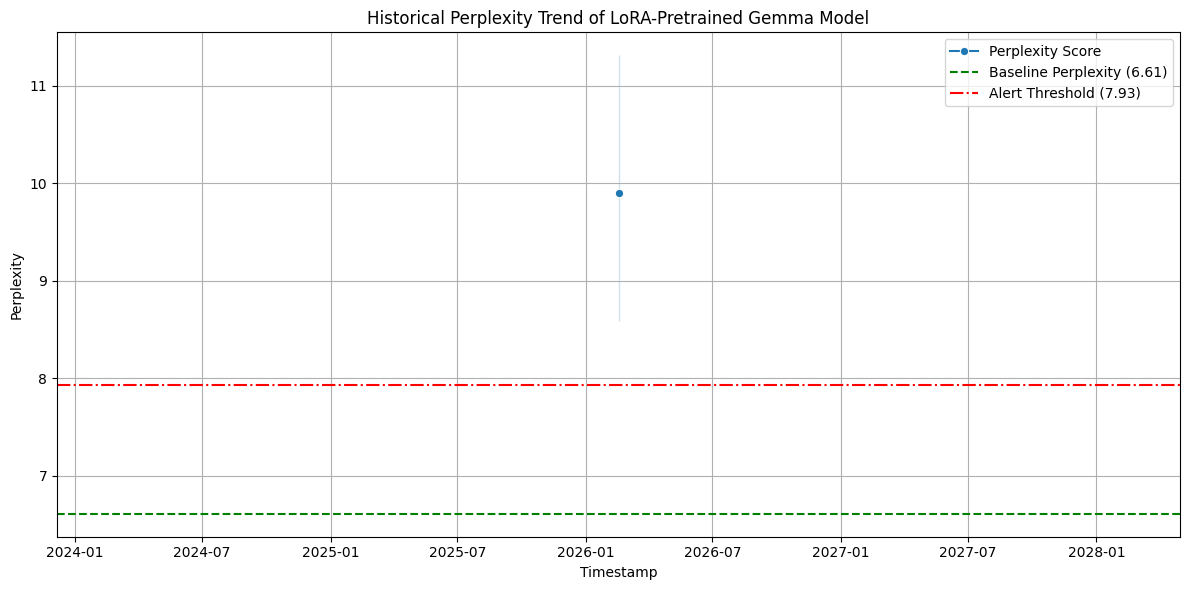

In [ ]:
if not historical_metrics_df.empty:
    baseline_perplexity = 6.608304739622196
    alert_threshold = baseline_perplexity * 1.20 # 20% above baseline

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=historical_metrics_df, x='timestamp', y='metric_value', marker='o', label='Perplexity Score')

    plt.axhline(y=baseline_perplexity, color='green', linestyle='--', label=f'Baseline Perplexity ({baseline_perplexity:.2f})')
    plt.axhline(y=alert_threshold, color='red', linestyle='-.', label=f'Alert Threshold ({alert_threshold:.2f})')

    plt.title('Historical Perplexity Trend of LoRA-Pretrained Gemma Model')
    plt.xlabel('Timestamp')
    plt.ylabel('Perplexity')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create plot as historical_metrics_df is empty.")